# Worksheet 5: End-to-End CNN for Image Classification
**Module:** 6CS012 Artificial Intelligence and Machine Learning  
**Student Name:** Luna Maharjan  
**Student ID:** 2418109


In [5]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Task 1: Data Understanding and Visualization

In [6]:
import os
import random
import matplotlib.pyplot as plt
from PIL import Image

In [7]:
import zipfile
import os

zip_path = "/content/drive/MyDrive/FruitinAmazon.zip"
extract_path = "/content/dataset"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Unzipped successfully")
print(os.listdir(extract_path))

Unzipped successfully
['FruitinAmazon']


In [8]:
print(os.listdir("/content/dataset"))

['FruitinAmazon']


In [9]:
train_dir = "/content/dataset/FruitinAmazon/train"

In [10]:
print(os.listdir("/content/dataset/FruitinAmazon"))

['train', 'test']


In [11]:
print(os.listdir(train_dir))

['guarana', 'pupunha', 'graviola', 'tucuma', 'acai', 'cupuacu']


In [12]:
import os
import random
import math
import matplotlib.pyplot as plt
from PIL import Image

In [13]:
train_dir = "/content/dataset/FruitinAmazon/train"

In [14]:
classes = sorted(os.listdir(train_dir))
print("Classes found:", classes)
print("Number of classes:", len(classes))

Classes found: ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']
Number of classes: 6


In [15]:
sample_images = []
sample_labels = []

for cls in classes:
    class_path = os.path.join(train_dir, cls)

    if os.path.isdir(class_path):
        image_files = os.listdir(class_path)

        if len(image_files) > 0:
            chosen_image = random.choice(image_files)
            image_path = os.path.join(class_path, chosen_image)

            sample_images.append(image_path)
            sample_labels.append(cls)

print("Total sampled images:", len(sample_images))

Total sampled images: 6


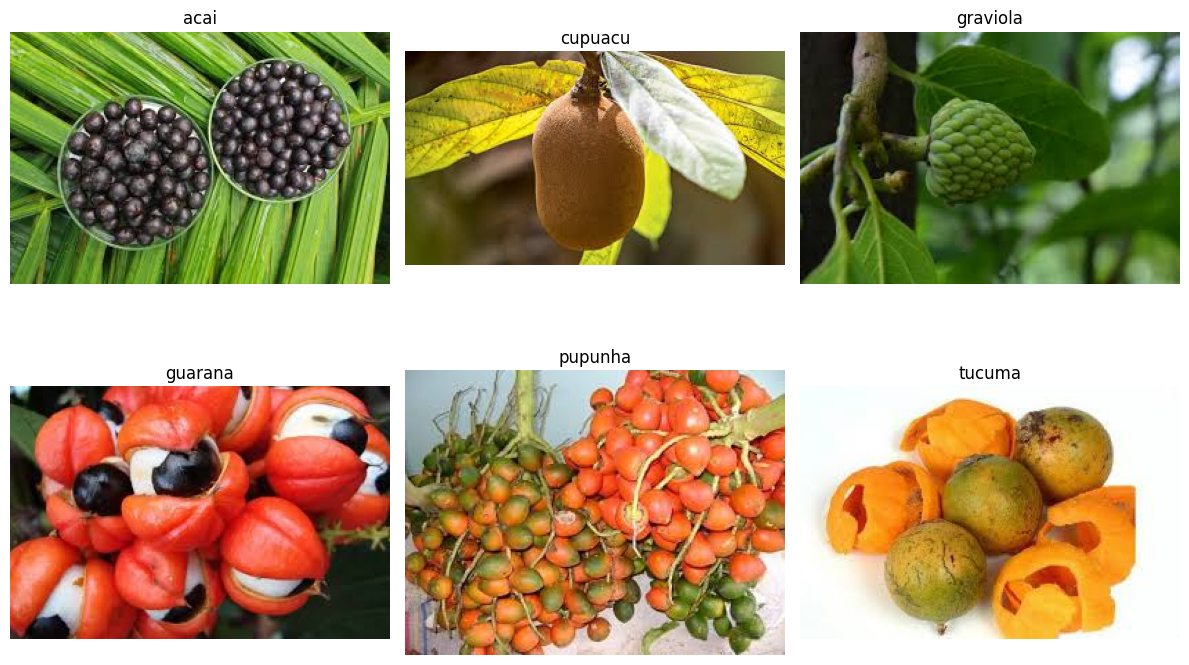

In [16]:
num_images = len(sample_images)
cols = math.ceil(num_images / 2)

plt.figure(figsize=(4 * cols, 8))

for i, img_path in enumerate(sample_images):
    img = Image.open(img_path)
    plt.subplot(2, cols, i + 1)
    plt.imshow(img)
    plt.title(sample_labels[i])
    plt.axis("off")

plt.tight_layout()
plt.show()

### Observation
The dataset contains multiple fruit classes stored in separate folders. Each class shows distinct visual features such as color, shape, and texture. Some variations in background and lighting are observed, which makes CNN suitable for feature extraction.

## Task 1 (Part 2): Corrupted Image Detection

In [17]:
corrupted_images = []

for cls in classes:
    class_path = os.path.join(train_dir, cls)

    if os.path.isdir(class_path):
        for img_name in os.listdir(class_path):
            img_path = os.path.join(class_path, img_name)

            try:
                with Image.open(img_path) as img:
                    img.verify()
            except (IOError, SyntaxError, OSError):
                corrupted_images.append(img_path)
                os.remove(img_path)
                print(f"Removed corrupted image: {img_path}")

if len(corrupted_images) == 0:
    print("No Corrupted Images Found")
else:
    print("Total corrupted images removed:", len(corrupted_images))

No Corrupted Images Found


## Task 2: Loading and Preprocessing Image Data

In [18]:
import tensorflow as tf
import numpy as np

In [19]:
train_dir = "/content/dataset/FruitinAmazon/train"
test_dir = "/content/dataset/FruitinAmazon/test"

img_height = 128
img_width = 128
batch_size = 16
validation_split = 0.2

In [20]:
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels="inferred",
    label_mode="int",
    image_size=(img_height, img_width),
    batch_size=batch_size,
    shuffle=True,
    validation_split=validation_split,
    subset="training",
    seed=123
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels="inferred",
    label_mode="int",
    image_size=(img_height, img_width),
    batch_size=batch_size,
    shuffle=False,
    validation_split=validation_split,
    subset="validation",
    seed=123
)

test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir,
    labels="inferred",
    label_mode="int",
    image_size=(img_height, img_width),
    batch_size=batch_size,
    shuffle=False
)

Found 90 files belonging to 6 classes.
Using 72 files for training.
Found 90 files belonging to 6 classes.
Using 18 files for validation.
Found 30 files belonging to 6 classes.


In [21]:
class_names = train_ds.class_names
print("Class names:", class_names)
print("Number of classes:", len(class_names))

Class names: ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']
Number of classes: 6


In [22]:
rescale = tf.keras.layers.Rescaling(1./255)

train_ds = train_ds.map(lambda x, y: (rescale(x), y))
val_ds = val_ds.map(lambda x, y: (rescale(x), y))
test_ds = test_ds.map(lambda x, y: (rescale(x), y))

###Task3: Implement CNN Architecture


In [23]:
from tensorflow.keras import layers, models

model = models.Sequential([
    layers.Input(shape=(128, 128, 3)),

    layers.Conv2D(32, (3, 3), padding="same", activation="relu"),
    layers.MaxPooling2D((2, 2), strides=2),

    layers.Conv2D(32, (3, 3), padding="same", activation="relu"),
    layers.MaxPooling2D((2, 2), strides=2),

    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dense(64, activation="relu"),
    layers.Dense(len(class_names), activation="softmax")
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     4,194,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,213,222 (16.07 MB)

 Trainable params: 4,213,222 (16.07 MB)

 Non-trainable params: 0 (0.00 B)

7. Task 4: Model Compilation

In [24]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [25]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

checkpoint = ModelCheckpoint(
    "best_cnn_model.h5",
    monitor="val_accuracy",
    save_best_only=True,
    mode="max",
    verbose=1
)

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True,
    verbose=1
)

In [26]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=250,
    callbacks=[checkpoint, early_stop]
)

Epoch 1/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 253ms/step - accuracy: 0.1979 - loss: 2.3535
Epoch 1: val_accuracy improved from None to 0.05556, saving model to best_cnn_model.h5



Epoch 1: finished saving model to best_cnn_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 372ms/step - accuracy: 0.2083 - loss: 2.2695 - val_accuracy: 0.0556 - val_loss: 1.9680
Epoch 2/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 254ms/step - accuracy: 0.3931 - loss: 1.5378
Epoch 2: val_accuracy improved from 0.05556 to 0.16667, saving model to best_cnn_model.h5



Epoch 2: finished saving model to best_cnn_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 321ms/step - accuracy: 0.4028 - loss: 1.5304 - val_accuracy: 0.1667 - val_loss: 1.4612
Epoch 3/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 261ms/step - accuracy: 0.5983 - loss: 1.3151
Epoch 3: val_accuracy improved from 0.16667 to 0.72222, saving model to best_cnn_model.h5



Epoch 3: finished saving model to best_cnn_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 336ms/step - accuracy: 0.6111 - loss: 1.2594 - val_accuracy: 0.7222 - val_loss: 1.2064
Epoch 4/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 254ms/step - accuracy: 0.6417 - loss: 1.0297
Epoch 4: val_accuracy did not improve from 0.72222
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 295ms/step - accuracy: 0.6667 - loss: 1.0057 - val_accuracy: 0.7222 - val_loss: 0.9353
Epoch 5/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 333ms/step - accuracy: 0.8663 - loss: 0.6611
Epoch 5: val_accuracy improved from 0.72222 to 0.83333, saving model to best_cnn_model.h5



Epoch 5: finished saving model to best_cnn_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 437ms/step - accuracy: 0.8472 - loss: 0.6556 - val_accuracy: 0.8333 - val_loss: 0.5880
Epoch 6/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 412ms/step - accuracy: 0.8896 - loss: 0.4392
Epoch 6: val_accuracy did not improve from 0.83333
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 473ms/step - accuracy: 0.8750 - loss: 0.4191 - val_accuracy: 0.8333 - val_loss: 0.5251
Epoch 7/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 300ms/step - accuracy: 0.9854 - loss: 0.1904
Epoch 7: val_accuracy improved from 0.83333 to 0.94444, saving model to best_cnn_model.h5



Epoch 7: finished saving model to best_cnn_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 380ms/step - accuracy: 0.9583 - loss: 0.2145 - val_accuracy: 0.9444 - val_loss: 0.4042
Epoch 8/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 262ms/step - accuracy: 0.9840 - loss: 0.1476
Epoch 8: val_accuracy did not improve from 0.94444
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 294ms/step - accuracy: 0.9722 - loss: 0.1578 - val_accuracy: 0.8889 - val_loss: 0.3917
Epoch 9/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 260ms/step - accuracy: 0.9913 - loss: 0.0915
Epoch 9: val_accuracy did not improve from 0.94444
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 305ms/step - accuracy: 0.9722 - loss: 0.1161 - val_accuracy: 0.8889 - val_loss: 0.3268
Epoch 10/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 253ms/step - accuracy: 0.9882 - loss: 0.0685
Epoch 10: val_accuracy did not improve from 0.94444
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 286ms/step - accuracy: 0.9722 - loss: 0.1297 - val_accuracy: 0.9444 - val_loss: 0.2929
Epoch 11/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 242ms/step - accuracy: 0.9799 - loss

###Accuracy and loss curves

In [27]:
test_loss, test_accuracy = model.evaluate(test_ds)
print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 149ms/step - accuracy: 0.6333 - loss: 0.9634
Test Loss: 0.9633588790893555
Test Accuracy: 0.6333333253860474


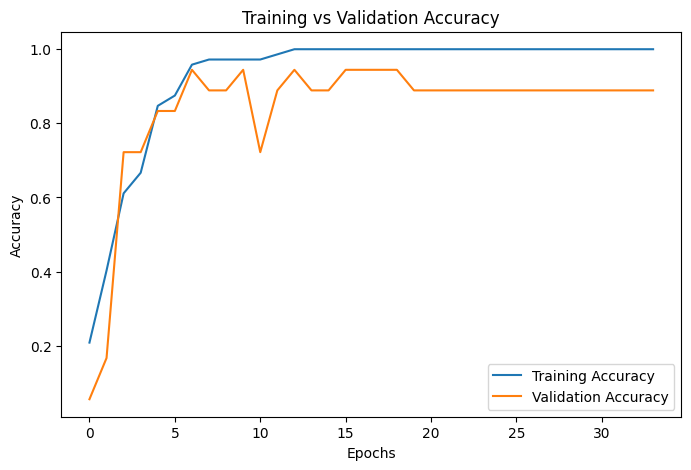

In [28]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.show()

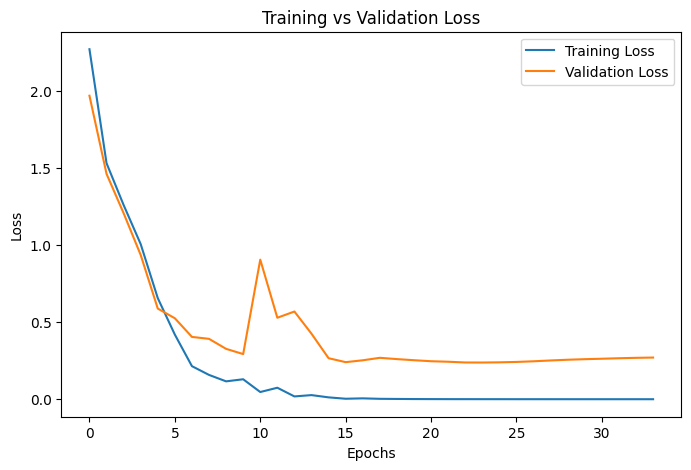

In [29]:
plt.figure(figsize=(8,5))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.show()

Task 8: Save and Load the Model

In [30]:
model.save("fruit_cnn_model.h5")
print("Model saved successfully")

Model saved successfully


In [31]:
loaded_model = tf.keras.models.load_model("fruit_cnn_model.h5")
loaded_loss, loaded_acc = loaded_model.evaluate(test_ds)
print("Loaded Model Test Loss:", loaded_loss)
print("Loaded Model Test Accuracy:", loaded_acc)

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 145ms/step - accuracy: 0.6333 - loss: 0.9634
Loaded Model Test Loss: 0.9633588790893555
Loaded Model Test Accuracy: 0.6333333253860474


Task 9: Predictions and Classification Report

In [32]:
from sklearn.metrics import classification_report

y_true = []
y_pred = []

for images, labels in test_ds:
    predictions = loaded_model.predict(images, verbose=0)
    predicted_labels = np.argmax(predictions, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(predicted_labels)

print(classification_report(y_true, y_pred, target_names=class_names))

              precision    recall  f1-score   support

        acai       0.71      1.00      0.83         5
     cupuacu       0.60      0.60      0.60         5
    graviola       0.71      1.00      0.83         5
     guarana       0.43      0.60      0.50         5
     pupunha       0.50      0.20      0.29         5
      tucuma       1.00      0.40      0.57         5

    accuracy                           0.63        30
   macro avg       0.66      0.63      0.60        30
weighted avg       0.66      0.63      0.60        30

